# YOLO26s — Training on Brackish Dataset

Three augmentation presets: **weak**, **medium**, **strong**.
Parameters identical to YOLOv8s experiment for fair comparison.

In [6]:
import os
from pathlib import Path
from ultralytics import YOLO

# switch cwd to project root so all relative paths (weights, data, runs) work
if Path.cwd().name == "notebooks":
    os.chdir("..")
print(f"Working dir: {Path.cwd()}")

import torch
print(f"PyTorch:     {torch.__version__}")
print(f"CUDA:        {torch.cuda.is_available()} — {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")

Working dir: d:\Slermo\Programming\Python\yolo_marine
PyTorch:     2.10.0+cu128
CUDA:        True — NVIDIA GeForce RTX 5060 Ti


In [ ]:
model = YOLO("yolo26s.pt")

model.train(
    data="configs/dataset.yaml",
    epochs=30,
    imgsz=640,
    batch=32,
    patience=10,
    device=0,
    workers=4,
    seed=42,
    # weak augmentation
    fliplr=0.5,
    hsv_h=0.014,
    hsv_s=0.1,
    hsv_v=0.1,
    degrees=0,
    translate=0.0,
    scale=0.0,
    # output
    project="../runs/yolo26s",
    name="weak",
)

New https://pypi.org/project/ultralytics/8.4.48 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.19  Python-3.12.3 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Ti, 16310MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=configs/dataset.yaml, degrees=0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.014, hsv_s=0.1, hsv_v=0.1, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=weak4, nbs=6

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000022D23CEACF0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
 

## Results

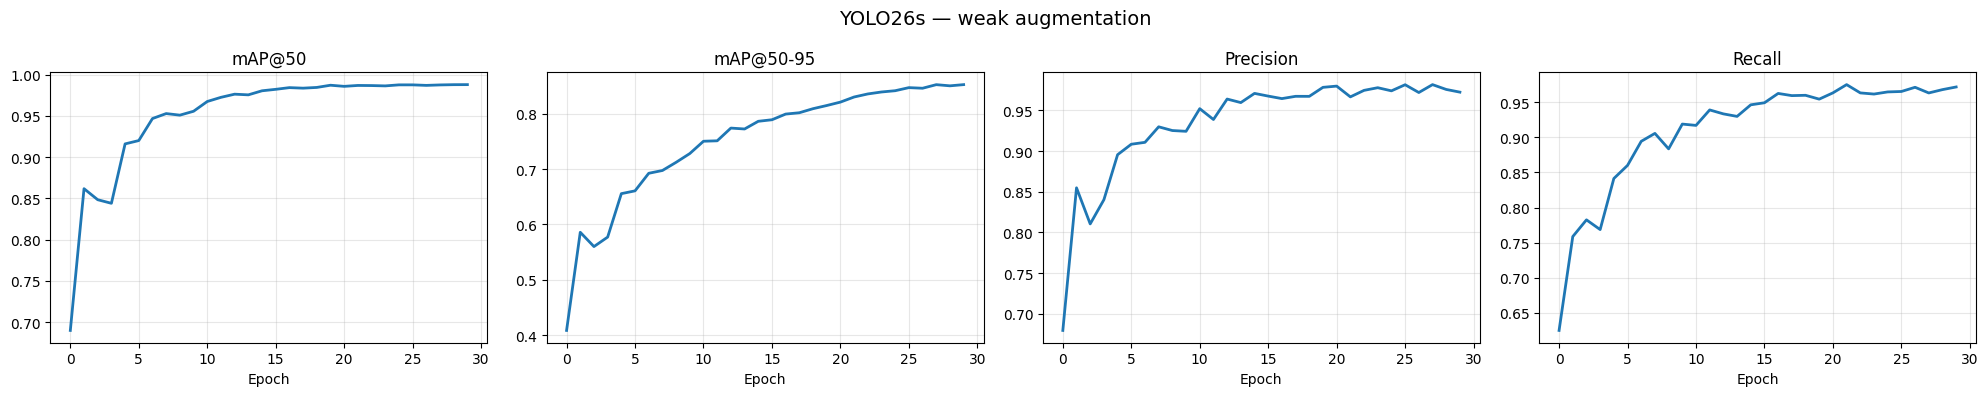


Best mAP@50:    0.9879  (epoch 30)
Best mAP@50-95: 0.8523  (epoch 30)


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("runs/detect/runs/yolo26s/weak4/results.csv", skipinitialspace=True)

metrics = {
    "mAP@50":    "metrics/mAP50(B)",
    "mAP@50-95": "metrics/mAP50-95(B)",
    "Precision":  "metrics/precision(B)",
    "Recall":     "metrics/recall(B)",
}

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, (title, col) in zip(axes, metrics.items()):
    ax.plot(df[col], linewidth=2)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.grid(True, alpha=0.3)

plt.suptitle("YOLO26s — weak augmentation", fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nBest mAP@50:    {df[metrics['mAP@50']].max():.4f}  (epoch {df[metrics['mAP@50']].argmax() + 1})")
print(f"Best mAP@50-95: {df[metrics['mAP@50-95']].max():.4f}  (epoch {df[metrics['mAP@50-95']].argmax() + 1})")

## Evaluate on test set

In [9]:
best = YOLO("runs/detect/runs/yolo26s/weak4/weights/best.pt")

metrics = best.val(
    data="configs/dataset.yaml",
    split="test",
    batch=1,
    device=0,
    plots=True,
)

print(f"mAP@50:      {metrics.box.map50:.4f}")
print(f"mAP@50-95:   {metrics.box.map:.4f}")
print(f"Precision:   {metrics.box.mp:.4f}")
print(f"Recall:      {metrics.box.mr:.4f}")

print(f"\nInference speed: {metrics.speed}")

print("\nPer-class AP@50:")
for i, name in metrics.names.items():
    print(f"  {name:12s}  {metrics.box.ap50[i]:.4f}")

Ultralytics 8.4.19  Python-3.12.3 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Ti, 16310MiB)
YOLO26s summary (fused): 122 layers, 9,467,502 parameters, 0 gradients, 20.5 GFLOPs
val: Fast image access  (ping: 0.20.0 ms, read: 18.81.9 MB/s, size: 321.4 KB)
val: Scanning D:\Slermo\Programming\Python\yolo_marine\data\brackish-dataset\labels\test... 1468 images, 229 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1468/1468 242.2it/s 6.1s<0.0s
val: New cache created: D:\Slermo\Programming\Python\yolo_marine\data\brackish-dataset\labels\test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1468/1468 55.8it/s 26.3s<0.1s
                   all       1468       3466      0.964      0.949      0.981      0.843
                  fish        321        321      0.978      0.971      0.992      0.882
            small_fish        247        965      0.944      0.922      0.971       0.72
                  crab        614       1279    